# Profile interpolation, development

In [1]:
# os tools
import sys
import os
import os.path
import requests
import time
import urllib3
import shutil
from tqdm import tqdm

# data tools
import numpy                 as np
import pandas                as pd
import xarray                as xr
from   datetime              import date, datetime, timedelta                 # for saving figures with today's date
import datetime
import scipy
from   scipy.stats           import kruskal              # for boxenplot stats
from   scipy.stats           import mannwhitneyu         # for split violin plot stats
import gsw


# for all plots
import matplotlib
import matplotlib.pyplot     as plt                      # needed to make map setup
import matplotlib.colors     as colors
from   matplotlib.ticker     import EngFormatter         # for degree symbol in axis
from   cmocean               import cm as cmo
import seaborn               as     sns

# for map
import shapefile
import cartopy                                           # to make map
import matplotlib.path       as     mpath                # to draw circle for map
import cartopy.crs           as     ccrs                 # for map projection
import cartopy.feature       as     cfeature             # to add land features to map
# from   xhistogram.xarray     import histogram            # for map histogram
# from   mycolorpy             import colorlist as mcp     # to get n colors list
import pyproj  
import geopandas             as     gpd                  # for adding shapefiles of frontal zones 
from   osgeo                 import gdal
# import scikit_posthocs       as     sp                   # for stats


xr.set_options(display_expand_attrs = False)

In [2]:
# Custom modules
import mod_cremas as crx 
import mod_ocean as myocn
import mod_argo 

from importlib import reload
import mod_plotting as myplt

plt.rcParams.update(myplt.my_params(size=12))

import shapefile
so_fronts = shapefile.Reader('./shapefiles/fronts/so_fronts.shp') 
stf_mod   = shapefile.Reader('./shapefiles/fronts/stf_mod/stf_mod.shp')

stf  = stf_mod.shape(0).points
saf  = so_fronts.shape(1).points
pf   = so_fronts.shape(2).points
sacc = so_fronts.shape(3).points
sie  = so_fronts.shape(4).points

max_latitude:          float = -30
add_gridlines:         bool  = True
color_land:            bool  = False
land_edgecolor:        str   = 'grey'
land_facecolor:        str   = 'grey'
fontsize:              float = 10
map_facecolor:         str   = 'white'
coast_linewidth:       float = 0.3
gridlines_linewidth:   float = 0.5
girdlines_color:       str   = 'grey'
gridlines_alpha:       float = 0.5
longitude_label_color: str   = 'grey'
latitude_label_color:  str   = 'grey'



In [3]:
datepath = '20250218'
coreDS = xr.open_dataset('../working-vars/argo/coreDS_qc_interp_2014-2023_acc' + datepath + '.nc')
core_INDEX = xr.open_dataset('../working-vars/argo/core_INDEX_qc_interp_2014-2023_acc' + datepath + '.nc')

/opt/homebrew/Caskroom/mambaforge/base/envs/cremas/lib/python3.9/site-packages/xarray/coding/times.py:254: RuntimeWarning: invalid value encountered in cast
  flat_num_dates_ns_int = (flat_num_dates * _NS_PER_TIME_DELTA[delta]).astype(


In [4]:
socat_3h = pd.read_csv('../data/SOCATv2024_SO_resampled_3h_median_2025Jan21.csv')
socat_3h['yearday'] = myocn.datetime2ytd(socat_3h['datetime'].astype('datetime64[ns]'), ref_time='2014-01-01')

In [5]:
onefloat = coreDS.where(coreDS['wmoid'] == 5906030, drop=True)

/opt/homebrew/Caskroom/mambaforge/base/envs/cremas/lib/python3.9/site-packages/xarray/coding/times.py:254: RuntimeWarning: invalid value encountered in cast
  flat_num_dates_ns_int = (flat_num_dates * _NS_PER_TIME_DELTA[delta]).astype(
/opt/homebrew/Caskroom/mambaforge/base/envs/cremas/lib/python3.9/site-packages/xarray/coding/times.py:254: RuntimeWarning: invalid value encountered in cast
  flat_num_dates_ns_int = (flat_num_dates * _NS_PER_TIME_DELTA[delta]).astype(


In [6]:
onefloat

<xarray.Dataset>
Dimensions:      (profid: 165, pressure: 125)
Coordinates:
  * profid       (profid) object '5906030_id001' ... '5906030_id166'
  * pressure     (pressure) int64 5 10 15 20 25 30 ... 941 951 961 971 981 991
    yearday      (profid, pressure) float64 1.946e+03 1.946e+03 ... 3.573e+03
    latitude     (profid, pressure) float64 -51.35 -51.35 ... -47.72 -47.72
    longitude    (profid, pressure) float64 30.21 30.21 30.21 ... 111.0 111.0
    wmoid        (profid, pressure) float64 5.906e+06 5.906e+06 ... 5.906e+06
    datetime     (profid, pressure) datetime64[ns] 2019-05-01T08:58:59 ... 20...
Data variables:
    CT           (profid, pressure) float64 3.64 3.64 3.639 ... 3.042 2.998
    SA           (profid, pressure) float64 34.0 34.0 34.0 ... 34.61 34.62 34.62
    sigma0       (profid, pressure) float64 26.9 26.9 26.9 ... 27.44 27.45 27.45
    spice        (profid, pressure) float64 -0.506 -0.5063 ... -0.1335 -0.136
    temperature  (profid, pressure) float64 3.634 3.634 3.633 ... 3.108 3.065
    salinity     (profid, pressure) float64 33.84 33.84 33.84 ... 34.45 34.45
Attributes: (3)

In [8]:
bgc2014_qc = pd.read_csv('/Volumes/cremas-repo/data/bgc/L1-qc/bgc_qcflags1258_yr2014_acc20250220.csv', index_col=0)
bgc2014_qc

,profid,pressure,wmoid,latitude,longitude,datetime,yearday,CT,SA,sigma0,...,salinity_qc,pressure_qc,time_qc,position_qc,temp_error,psal_error,pres_error,pH,pH_qc,pH_error
5538312,5904184_id001,7.550000,5904184,-63.979,-150.024,2014-04-03 22:50:44.002000128,92.951898,0.062752,33.916040,27.101326,...,8,1,1,1,0.002,0.01,2.4,8.036440,1,0.015321
5538315,5904184_id001,11.730000,5904184,-63.979,-150.024,2014-04-03 22:50:44.002000128,92.951898,0.062162,33.915951,27.101285,...,8,1,1,1,0.002,0.01,2.4,8.037667,1,0.015321
5538319,5904184_id001,16.220001,5904184,-63.979,-150.024,2014-04-03 22:50:44.002000128,92.951898,0.062796,33.915852,27.101172,...,8,1,1,1,0.002,0.01,2.4,8.038201,1,0.015321
5538322,5904184_id001,21.660000,5904184,-63.979,-150.024,2014-04-03 22:50:44.002000128,92.951898,0.064599,33.915659,27.100925,...,8,1,1,1,0.002,0.01,2.4,8.038585,1,0.015321
5538326,5904184_id001,26.610000,5904184,-63.979,-150.024,2014-04-03 22:50:44.002000128,92.951898,0.063223,33.915310,27.100716,...,8,1,1,1,0.002,0.01,2.4,8.039553,1,0.015321
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6338291,5904478_id002,1798.860000,5904478,-64.998,0.004,2014-12-28 20:28:53.002000128,361.853391,0.035283,34.836521,27.841434,...,1,1,1,1,0.002,0.01,2.4,7.875041,1,0.023185
6338292,5904478_id002,1849.660000,5904478,-64.998,0.004,2014-12-28 20:28:53.002000128,361.853391,0.009414,34.835521,27.842022,...,1,1,1,1,0.002,0.01,2.4,7.873732,1,0.023193
6338293,5904478_id002,1899.860000,5904478,-64.998,0.004,2014-12-28 20:28:53.002000128,361.853391,-0.012504,34.834513,27.842384,...,1,1,1,1,0.002,0.01,2.4,7.873345,1,0.023200
6338294,5904478_id002,1949.760000,5904478,-64.998,0.004,2014-12-28 20:28:53.002000128,361.853391,-0.027938,34.833513,27.842402,...,1,1,1,1,0.002,0.01,2.4,7.872382,1,0.023204


# Handling gaps and surface value filling 

- Updated version with Hannah, Feb 24 2025

In [ ]:
# # Toy data
# x_data = np.array([[20.2, 26.56,  31.74,  36.6 ,  41.86,  46.7 ,  51.74,  56.32,  61.02, 66.88,  71.64,  76.79,  81.67,  86.59,  91.34,  96.56, 101.61, 221, 236, 259, np.nan],
#                    [19.6, 27.06,  32.24,  37.1 ,  42.36,  47.2 ,  52.24,  56.82,  61.52, 67.38,  72.14,  77.29,  82.17,  87.09,  91.84,  97.06, 102.11, 287, 307, 371, 569]])

# y_data = np.array([[26.6, 26.93, 26.86, 26.9 , 26.79, 26.9 , 26.81, 26.81, 26.91, 27.45, 27.74, 28.37, 28.93, 29.17, 29.74, 30.21, 30.69, 30.9, 30.7, 30.8, np.nan],
#                    [28.7, 28.93, 28.86, 28.9 , 28.79, 28.9 , 28.81, 28.81, 28.91, 29.45, 29.74, 30.37, 30.93, 31.17, 31.74, 32.21, 32.69, 32.4, 32.5, 32.55, 32.7]])

# x_interp = np.arange(0,100,10)


In [ ]:
# %% Song's adaptation
# Moved to mod_ocean
# Argo specific version in mod_argo (treating pressure as x)
# =============================================================================
def custom_interp(x_data, y_data, x_levels, x_fill=25):
    """  
    Adapting for Hannah, from mod_argo interpolate_z_profile()
    Function to interpolate single float profile data (pchip) to chosen pressure levels,
    Does not fit over vertical gaps in the data, with cutoff defined by x_gap. 

    @param      x_data: 1D array of x-values (pressure), length N
                y_data: 1D array of y-values (T, S, NO3, O2, etc), length N
                x_levels: 1D array of pressure levels to interpolate to, length N
                x_fill: (default 25) fill pressures up to surface with uppermost value in profile
                        if that value has pressure < 25dbar
    @return     output: pd DataFrame with interpolated data
    """
    # Initialize a dataframe for observed values
    # May want to do some exception handling here (pressure sorting, drop duplicates)
    prof = pd.DataFrame({'x': x_data, 'y': y_data}).dropna()
    prof = prof.sort_values(by='x')
    prof = prof.drop_duplicates(subset='x', keep='first')

    # Initialize dataFrame to return interpolated values, with x_levels as index
    output = pd.DataFrame(index=x_levels, columns=['y_interp'], dtype=float)
    output.index.name='x_interp'

    # ===== GAP FILLING
    # Compute the maximum gap
    x_gap = get_max_gap(prof['x'].values.max()) 
    # x_gap = 100

    # Separate out continuous sections by defining new variable
    prof['x_diff'] = [np.nan] + np.diff(prof['x']).tolist()

    # Dyanmic gap filling
    prof['max_allowed_gap'] = [get_max_gap(x) for x in prof['x']]
    subID_index = prof[prof['x_diff'] > prof['max_allowed_gap']].index

    prof.loc[subID_index, 'marker'] = 1
    prof['continuous_id'] = prof['marker'].cumsum().ffill().fillna(0).astype(int)

    # If there are no gaps, all points will be assigned to same continuous_id
    # Fit pchip to each continuous_id 
    for _, subprof in prof.groupby('continuous_id'):
        xmin = subprof['x'].min(); xmax = subprof['x'].max()
        subx_levels = [x for x in x_levels if x > xmin and x < xmax] # valid pres levels
        if len(subprof) > 1: # If there is more than 1 point to fit pchip over
            f = scipy.interpolate.PchipInterpolator(x=subprof['x'], y=subprof['y'], extrapolate = False)
            output.loc[subx_levels, 'y_interp'] = f(subx_levels)

    # ==== HANDLE SURFACE GAPS 
    # Note that by default, pchip without extrapolation will fill surface values < minimum
    # Fill surface with the nearest neighbor if the first observed value is below x_fill = 25
    first_obs = prof.iloc[0]
    if first_obs['x'] < x_fill:
        # Decide here if you want to fill with first interpolated value, or first observed value
        # fill_value = output.dropna().iloc[0].y_interp
        fill_value = prof.iloc[0].y
        
        # Determine surface index values to fill
        fill_index = [x for x in output.index if x < first_obs.x]
        output.loc[fill_index, 'y_interp'] = np.tile(fill_value, len(fill_index))

        
    return output.y_interp.values
    

In [ ]:
# UNPACKED FUNCTION FOR TESTING

x_fill=get_max_gap(prof['x'].values.max()) 
# Initialize a dataframe for observed values
# May want to do some exception handling here (pressure sorting, drop duplicates)
prof = pd.DataFrame({'x': x_data, 'y': y_data}).dropna()
prof = prof.sort_values(by='x')
prof = prof.drop_duplicates(subset='x', keep='first')

# Initialize dataFrame to return interpolated values, with x_interp as index
output = pd.DataFrame(index=x_interp, columns=['y_interp'], dtype=float)
output.index.name='x_interp'

# ===== GAP FILLING
# Compute the maximum gap
# x_gap = get_max_gap(prof['x'].values) 
x_gap = 100

# Separate out continuous sections by defining new variable
prof['x_diff'] = [np.nan] + np.diff(prof['x']).tolist()

# Dyanmic gap filling
prof['max_allowed_gap'] = [get_max_gap(x) for x in prof['x']]
subID_index = prof[prof['x_diff'] > prof['max_allowed_gap']].index

prof.loc[subID_index, 'marker'] = 1
prof['continuous_id'] = prof['marker'].cumsum().ffill().fillna(0).astype(int)

# If there are no gaps, all points will be assigned to same continuous_id
# Fit pchip to each continuous_id 
for _, subprof in prof.groupby('continuous_id'):
    xmin = subprof['x'].min(); xmax = subprof['x'].max()
    subx_interp = [x for x in x_interp if x > xmin and x < xmax] # valid pres levels
    if len(subprof) > 1: # If there is more than 1 point to fit pchip over
        f = scipy.interpolate.PchipInterpolator(x=subprof['x'], y=subprof['y'], extrapolate = False)
        output.loc[subx_interp, 'y_interp'] = f(subx_interp)

# ==== HANDLE SURFACE GAPS 
# Note that by default, pchip without extrapolation will fill surface values < minimum
# Fill surface with the nearest neighbor if the first observed value is below x_fill
first_obs = prof.iloc[0]
if first_obs['x'] < x_fill:
    # Decide here if you want to fill with first interpolated value, or first observed value
    # print(output)
    fill_value = output.dropna().iloc[0].y_interp
    # fill_value = prof.iloc[0].y

    # Determine surface index values to fill
    fill_index = [x for x in output.index if x < first_obs.x]
    output.loc[fill_index, 'y_interp'] = np.tile(fill_value, len(fill_index))

In [ ]:
prof

,x,y,x_diff,max_allowed_gap,marker,continuous_id
0,20.20,26.60,NaN,25,NaN,0
1,26.56,26.93,6.36,25,NaN,0
2,31.74,26.86,5.18,25,NaN,0
3,36.60,26.90,4.86,25,NaN,0
4,41.86,26.79,5.26,25,NaN,0
5,71.64,27.74,29.78,25,1.0,1
6,76.79,28.37,5.15,25,NaN,1
7,81.67,28.93,4.88,25,NaN,1
8,86.59,29.17,4.92,25,NaN,1
9,91.34,29.74,4.75,25,NaN,1


In [ ]:
output

,y_interp
x_interp,
0,26.878389
10,26.878389
20,26.878389
30,26.878389
40,26.849560
50,NaN
60,NaN
70,NaN
80,28.773151


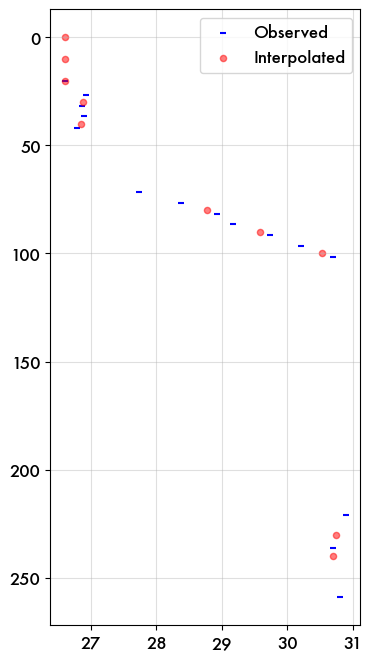

In [ ]:
# 
# 
x_data = np.array([20.2, 26.56,  31.74,  36.6 ,  41.86,  71.64,  76.79,  81.67,  86.59,  91.34,  96.56, 101.61, 221, 236, 259, np.nan])
y_data = np.array([26.6, 26.93, 26.86, 26.9 , 26.79, 27.74, 28.37, 28.93, 29.17, 29.74, 30.21, 30.69, 30.9, 30.7, 30.8, np.nan])
x_interp = np.arange(0,250,10)

y_interp = custom_interp(x_data, y_data, x_interp)
# print(y_interp)

fig = plt.figure(figsize=(4,8))
ax = fig.add_subplot(111)

ax.scatter(y_data, x_data, color='b', s=15, marker='_', label='Observed')
ax.scatter(y_interp, x_interp, color='red', alpha=0.5, s=20, label='Interpolated')
ax.invert_yaxis()
ax.legend()
ax.grid(alpha=0.4)

## From mod_Argo

In [9]:
onefloat

<xarray.Dataset>
Dimensions:      (profid: 165, pressure: 125)
Coordinates:
  * profid       (profid) object '5906030_id001' ... '5906030_id166'
  * pressure     (pressure) int64 5 10 15 20 25 30 ... 941 951 961 971 981 991
    yearday      (profid, pressure) float64 1.946e+03 1.946e+03 ... 3.573e+03
    latitude     (profid, pressure) float64 -51.35 -51.35 ... -47.72 -47.72
    longitude    (profid, pressure) float64 30.21 30.21 30.21 ... 111.0 111.0
    wmoid        (profid, pressure) float64 5.906e+06 5.906e+06 ... 5.906e+06
    datetime     (profid, pressure) datetime64[ns] 2019-05-01T08:58:59 ... 20...
Data variables:
    CT           (profid, pressure) float64 3.64 3.64 3.639 ... 3.042 2.998
    SA           (profid, pressure) float64 34.0 34.0 34.0 ... 34.61 34.62 34.62
    sigma0       (profid, pressure) float64 26.9 26.9 26.9 ... 27.44 27.45 27.45
    spice        (profid, pressure) float64 -0.506 -0.5063 ... -0.1335 -0.136
    temperature  (profid, pressure) float64 3.634 3.634 3.633 ... 3.108 3.065
    salinity     (profid, pressure) float64 33.84 33.84 33.84 ... 34.45 34.45
Attributes: (3)

In [10]:
# # UNPACKED FUNCTION FROM MOD_ARGO FOR DEV
# prof = tester[tester.profid=='5906030_id003']
# pres_levels = np.arange(0, 250, 10)
# var_list = ['CT', 'SA', 'sigma0', 'spice', 'temperature', 
#                         'salinity', 'yearday', 'latitude', 'longitude']
# z_gap = 200


# try:
#     # Sort by pressure and drop duplicates
#     prof = prof.reset_index().sort_values(by='pressure')
#     prof = prof.drop_duplicates(subset='pressure', keep="last") 
#     prof['pres_diff'] = [np.nan] + np.diff(prof.pressure).tolist()

#     # Choose static gap filling
#     subID_index = prof[prof['pres_diff'] > z_gap].index

#     # # Or dynamic gap filling
#     # prof['max_allowed_gap'] = [get_max_gap(x) for x in prof['x']]
#     # subID_index = prof[prof['x_diff'] > prof['max_allowed_gap']].index

#     # Separate out continuous ID's
#     prof.loc[subID_index, 'marker'] = 1
#     prof['continuous_id'] = prof['marker'].cumsum().ffill().fillna(0).astype(int)
# except: 
#     # print('no data in profid' + str(prof.profid.iloc[0]))
#    pass

# # Initialize interpolated DataFrame to return, with pressure as index
# output = pd.DataFrame(index=pres_levels, columns=var_list, dtype=float)
# output.index.name = 'pressure'

# # If there are no gaps, all points will be assigned to same continuous_id
# # Fit pchip to each continuous_id 
# for _, subprof in prof.groupby('continuous_id'):
#     # subprof = subprof.dropna()
#     xmin = subprof.pressure.min(); xmax = subprof.pressure.max()
#     subpres_levels = [x for x in pres_levels if x > xmin and x < xmax] # valid pres levels
#     if len(subprof) > 1: # If there is more than 1 point to fit pchip over
#         for var in var_list:
#             print(subprof[var])
#             subprof = subprof.dropna(subset=[var])
#             f = scipy.interpolate.PchipInterpolator(x=subprof['pressure'], y=subprof[var], extrapolate = False)
#             output.loc[subpres_levels, var] = f(subpres_levels)

# # # ==== HANDLE SURFACE GAPS 
# # # Note that by default, pchip without extrapolation will fill surface values < minimum
# # # Fill surface with the nearest neighbor if the first observed value is below x_fill = 25
# # first_obs = prof.iloc[0]
# # if first_obs['x'] < x_fill:
# #     # Decide here if you want to fill with first interpolated value, or first observed value
# #     # fill_value = output.dropna().iloc[0].y_interp
# #     fill_value = prof.iloc[0].y
    
# #     # Determine surface index values to fill
# #     fill_index = [x for x in output.index if x < first_obs.x]
# #     output.loc[fill_index, 'y_interp'] = np.tile(fill_value, len(fill_index))

# # Reset index, drop nans (needed before datetime calculation)
# output = output.reset_index().dropna() 

In [ ]:
# list = []

# result = pd.
# for id, data in onefloat.CT.to_dataframe().groupby('profid'):
#     y_interp = custom_interp(data.reset_index().pressure.values, data.CT.values, x_interp)
#     list.append(y_interp)

In [ ]:
# tempdat = onefloat.CT.values
# presdat = onefloat.pressure.values

# # output = [];
# output = pd.DataFrame(index=x_interp, dtype=float)

# for i in range(len(tempdat)):
#     x_data = presdat
#     y_data = tempdat[i]
#     x_interp = np.arange(0,250,10)

#     # y_interp = custom_interp(x_data, y_data, x_interp)
#     output[]
#     output.append(y_interp)

output = pd.DataFrame(output).T
output.index.name = 'pressure'

In [12]:
bgc2014_qc

,profid,pressure,wmoid,latitude,longitude,datetime,yearday,CT,SA,sigma0,...,salinity_qc,pressure_qc,time_qc,position_qc,temp_error,psal_error,pres_error,pH,pH_qc,pH_error
5538312,5904184_id001,7.550000,5904184,-63.979,-150.024,2014-04-03 22:50:44.002000128,92.951898,0.062752,33.916040,27.101326,...,8,1,1,1,0.002,0.01,2.4,8.036440,1,0.015321
5538315,5904184_id001,11.730000,5904184,-63.979,-150.024,2014-04-03 22:50:44.002000128,92.951898,0.062162,33.915951,27.101285,...,8,1,1,1,0.002,0.01,2.4,8.037667,1,0.015321
5538319,5904184_id001,16.220001,5904184,-63.979,-150.024,2014-04-03 22:50:44.002000128,92.951898,0.062796,33.915852,27.101172,...,8,1,1,1,0.002,0.01,2.4,8.038201,1,0.015321
5538322,5904184_id001,21.660000,5904184,-63.979,-150.024,2014-04-03 22:50:44.002000128,92.951898,0.064599,33.915659,27.100925,...,8,1,1,1,0.002,0.01,2.4,8.038585,1,0.015321
5538326,5904184_id001,26.610000,5904184,-63.979,-150.024,2014-04-03 22:50:44.002000128,92.951898,0.063223,33.915310,27.100716,...,8,1,1,1,0.002,0.01,2.4,8.039553,1,0.015321
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6338291,5904478_id002,1798.860000,5904478,-64.998,0.004,2014-12-28 20:28:53.002000128,361.853391,0.035283,34.836521,27.841434,...,1,1,1,1,0.002,0.01,2.4,7.875041,1,0.023185
6338292,5904478_id002,1849.660000,5904478,-64.998,0.004,2014-12-28 20:28:53.002000128,361.853391,0.009414,34.835521,27.842022,...,1,1,1,1,0.002,0.01,2.4,7.873732,1,0.023193
6338293,5904478_id002,1899.860000,5904478,-64.998,0.004,2014-12-28 20:28:53.002000128,361.853391,-0.012504,34.834513,27.842384,...,1,1,1,1,0.002,0.01,2.4,7.873345,1,0.023200
6338294,5904478_id002,1949.760000,5904478,-64.998,0.004,2014-12-28 20:28:53.002000128,361.853391,-0.027938,34.833513,27.842402,...,1,1,1,1,0.002,0.01,2.4,7.872382,1,0.023204


In [ ]:
# 1. TESTING MODIFIED METHOD IN MOD_ARGO
pid = '5904396_id021'

pid = np.random.choice(bgc2014_qc.profid.unique())
oneprof = bgc2014_qc[bgc2014_qc.profid==pid]
# tester = pd.concat([oneprof.iloc[0:25], oneprof.iloc[40:50], oneprof.iloc[55:60]])
subset = pd.concat([oneprof[(oneprof.pressure > 15) & (oneprof.pressure < 50)],
                    oneprof[(oneprof.pressure > 80) & (oneprof.pressure < 130)],
                    oneprof[(oneprof.pressure > 160) & (oneprof.pressure < 200)],
                    oneprof[(oneprof.pressure > 300) & (oneprof.pressure < 500)]])

reload(mod_argo)
interp_dynamic = mod_argo.regrid_pressure_levels(bgc2014_qc, 
                                            np.arange(0,400,10), var_list=['CT'],
                                            bgc_list=[], 
                                            z_gap = 'dynamic',
                                            surface_fill = 25,
                                            ref_time = '2014-01-01').reset_index()

interp_gap = mod_argo.regrid_pressure_levels(bgc2014_qc, 
                                            np.arange(0,400,10), var_list=['CT'],
                                            bgc_list=[], 
                                            z_gap = 50,
                                            ref_time = '2014-01-01').reset_index()

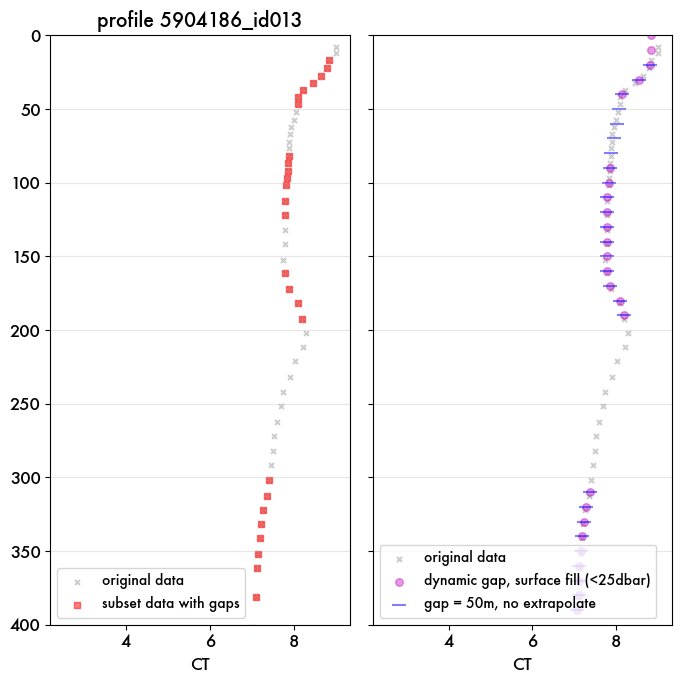

In [18]:
# 2. VISUALIZE TESTING
# =============================== 
# Visualize comparison data 

fig, axs = plt.subplots(1, 2, figsize=[7, 7], layout='tight', sharey=True) # inches
axs = axs.flatten()

for ax in axs[0:1]:
    ax.scatter(oneprof.CT, oneprof.pressure, s=13, marker= 'x', c= 'k', alpha=0.2, label='original data')
    ax.scatter(subset.CT, subset.pressure, s=15, marker= 's', c='r', alpha=0.5, label='subset data with gaps')
    ax.invert_yaxis()
    ax.set_title('profile ' + str(pid))
    
for ax in axs[1:2]:
    ax.scatter(oneprof.CT, oneprof.pressure, s=13, marker= 'x', c= 'k', alpha=0.2, label='original data')
    # ax.scatter(oneprof.CT, oneprof.pressure, s=35, marker= 's', c='r', alpha=0)
#     ax.scatter(out_old.CT, out_old.pressure, s=20, c='c', alpha=0.5, label='old method')
    ax.scatter(interp_dynamic.CT, interp_dynamic.pressure, s=30, c='m', alpha=0.4, label='dynamic gap, surface fill (<25dbar)')
    ax.scatter(interp_gap.CT, interp_gap.pressure, s=100, c='b', marker= '_', alpha=0.5, label='gap = 50m, no extrapolate')
    # ax.set_title('interpolated, z_gap=' + str(z_gap))

for ax in axs:
    ax.grid(alpha=0.3, zorder=1, axis='y')
    ax.legend(loc='lower left', fontsize=10)
    ax.set_ylim([400,0])
    ax.set_xlabel('CT')
    # ax.invert_yaxis()

In [ ]:
onefloat = bgc2014_qc

### other tester data

In [11]:
testfloat = xr.open_dataset('/Users/sangminsong/Library/CloudStorage/OneDrive-UW/Code/CREMAS/data/argopy_5906030_bgc_profiles_2025Jan29.nc').to_dataframe().reset_index()

In [282]:
testfloat = testfloat.to_dataframe().reset_index()

In [ ]:
profile = onefloat.sel(profid='5906030_id002')

x_data = profile.pressure.values
y_data = profile.CT.values
y_interp = custom_interp(x_data, y_data, x_interp)


In [35]:
x_data = np.array([[20.2, 26.56,  31.74,  36.6 ,  41.86,  46.7 ,  51.74,  56.32,  61.02, 66.88,  71.64,  76.79,  81.67,  86.59,  91.34,  96.56, 101.61, 221, 236, 259, np.nan],
                   [19.6, 27.06,  32.24,  37.1 ,  42.36,  47.2 ,  52.24,  56.82,  61.52, 67.38,  72.14,  77.29,  82.17,  87.09,  91.84,  97.06, 102.11, 287, 307, 371, 569]])

y_data = np.array([[26.6, 26.93, 26.86, 26.9 , 26.79, 26.9 , 26.81, 26.81, 26.91, 27.45, 27.74, 28.37, 28.93, 29.17, 29.74, 30.21, 30.69, 30.9, 30.7, 30.8, np.nan],
                   [28.7, 28.93, 28.86, 28.9 , 28.79, 28.9 , 28.81, 28.81, 28.91, 29.45, 29.74, 30.37, 30.93, 31.17, 31.74, 32.21, 32.69, 32.4, 32.5, 32.55, 32.7]])

x_interp = np.arange(0,100,10)

# Call the custom interpolation function
y_interp = custom_interpolate(x_data, y_data, x_interp)

print("x to interpolate to:\n", x_interp)
print("Interpolated values:\n", y_interp)

# Plot
plt.plot(x_interp, y_interp[1], '-', label='PCHIP interpolation')
plt.plot(x_data[1], y_data[1], 'o', label='Data points')
plt.plot(x_interp, y_interp[1], 'o', label='PCHIP interpolation')
plt.legend()
plt.show()

NameError: name 'pchip_interpolate' is not defined